In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from utils import pipeline

In [9]:
%matplotlib inline
sns.set_style('whitegrid')

In [10]:
# load dataset
df = pd.read_csv('../data/TelcoCustomerChurn.csv')

In [11]:

X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print("\nTraining Set:")
print("X_train", X_train.shape)
print("y_train", y_train.value_counts())
print("y_train %", y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest Set:")
print("X_test", X_test.shape)
print("y_test", y_test.value_counts())
print("y_test %", y_test.value_counts(normalize=True).mul(100).round(2))



Training Set:
X_train (4930, 20)
y_train Churn
0    3622
1    1308
Name: count, dtype: int64
y_train % Churn
0    73.47
1    26.53
Name: proportion, dtype: float64

Test Set:
X_test (2113, 20)
y_test Churn
0    1552
1     561
Name: count, dtype: int64
y_test % Churn
0    73.45
1    26.55
Name: proportion, dtype: float64


Baseline — Train acc: 0.814 | Test acc: 0.795
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.87      1552
       Churn       0.65      0.50      0.56       561

    accuracy                           0.80      2113
   macro avg       0.74      0.70      0.71      2113
weighted avg       0.78      0.80      0.79      2113

ROC-AUC: 0.821


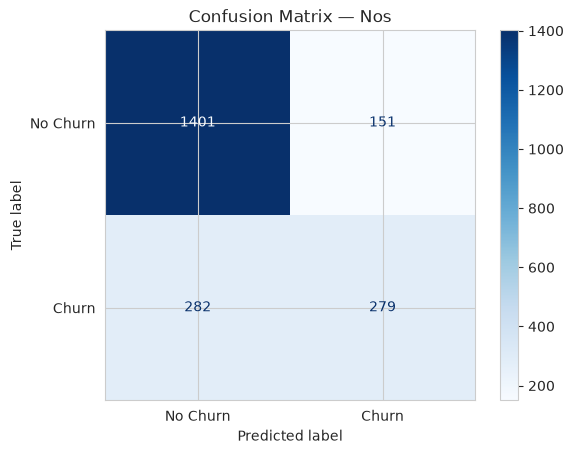

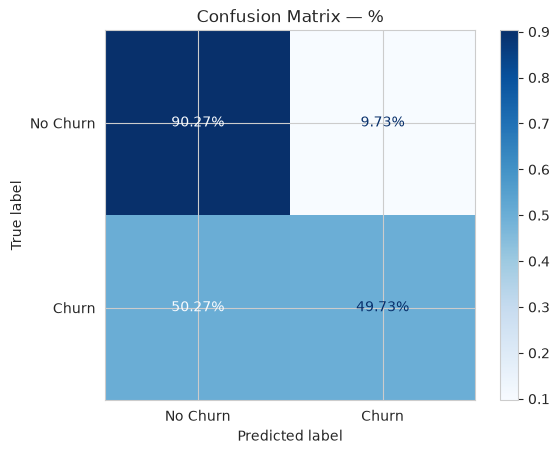

In [12]:
pipeline.fit(X_train, y_train)
train_acc1 = pipeline.score(X_train, y_train)
test_acc1 = pipeline.score(X_test, y_test)
print(f"Baseline — Train acc: {train_acc1:.3f} | Test acc: {test_acc1:.3f}")

y_pred1 = pipeline.predict(X_test)
y_proba1 = pipeline.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred1, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba1):.3f}")

# confusion matrix - nos
cm = confusion_matrix(y_test, y_pred1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Nos')
plt.show()
# confusion matrix - pct
cm_pct = confusion_matrix(y_test, y_pred1, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pct, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', values_format='.2%')
plt.title('Confusion Matrix — %')
plt.show()

In [13]:
import joblib

joblib.dump(pipeline, '../model/telco_churn_pipeline.joblib')

['../model/telco_churn_pipeline.joblib']

In [14]:
pipeline = joblib.load('../model/telco_churn_pipeline.joblib')

new_customer = pd.DataFrame([{
    'customerID': '9999-XYZ', 'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes',
    'Dependents': 'No', 'tenure': 5, 'PhoneService': 'Yes', 'MultipleLines': 'No',
    'InternetService': 'Fiber optic', 'OnlineSecurity': 'No', 'OnlineBackup': 'No',
    'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'No', 'StreamingMovies': 'No',
    'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 85.0, 'TotalCharges': '425.0'
}])

pred = pipeline.predict(new_customer)
proba = pipeline.predict_proba(new_customer)[:, 1]
print(f"Churn: {pred[0]}, probability: {proba[0]:.3f}")

Churn: 1, probability: 0.557
